# DC Housing Market Machine Learning Forecasting

This notebook demonstrates the application of machine learning models to forecast the DC housing market index. We'll use several different modeling approaches and compare their performance.

In [20]:
# Import utility functions
import dc_housing_ml_utils as utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import RandomizedSearchCV

# Suppress warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Set random seed for reproducibility
np.random.seed(42)

## 1. Granger Causality Testing

We'll first conduct Granger causality tests to identify variables that have predictive power for our target variable.

In [21]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# Load the dataset
try:
    df = pd.read_csv('DC_Master_ARIMA_Filled_pct_change_dummies.csv', parse_dates=['Date'], index_col='Date')
    df = df[df.index <= '2024-10-01']
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'DC_Master_ARIMA_Filled_pct_change_dummies.csv' not found.")
    # Exit or handle error appropriately if file not found
    raise
except Exception as e:
    print(f"Error loading dataset: {e}")
    # Exit or handle other loading errors
    raise

Dataset loaded successfully.


In [22]:
# Define stationary columns for testing
stationary_cols = [
    'Unemployment_Rate', # Already I(0)
    'Interest_Rate_pct_change',
    'Mortgage_Rate_pct_change',
    'CPI_pct_change',
    'House_Index_pct_change',
    'Poverty_Rate_pct_change',
    'Median_Household_Income_pct_change',
    'GDP_pct_change',
    'Population_pct_change'
]

# Verify columns exist in the DataFrame
missing_cols = [col for col in stationary_cols if col not in df.columns]
if missing_cols:
    print(f"Error: The following expected stationary columns are missing: {missing_cols}")
    # Filter out missing columns to proceed or exit
    stationary_cols = [col for col in stationary_cols if col in df.columns]
    if not stationary_cols:
        print("No stationary columns found to perform tests. Exiting.")
        raise ValueError("No stationary columns found")
    else:
        print(f"Proceeding with available columns: {stationary_cols}")

In [23]:
# Select only the stationary columns
df_stationary = df[stationary_cols].copy()

# Handle Missing Values
# Granger causality tests require non-missing values.
initial_rows = len(df_stationary)
df_stationary.dropna(inplace=True)
final_rows = len(df_stationary)
print(f"Removed {initial_rows - final_rows} rows with NaN values.")

if final_rows < 10: # Need sufficient data points for the test
     print(f"Warning: Only {final_rows} complete observations available after handling NaNs. Results might be unreliable.")
     if final_rows == 0:
         print("Error: No complete observations left after removing NaNs. Cannot perform Granger Causality tests.")
         raise ValueError("No observations after NaN removal")

Removed 0 rows with NaN values.


In [24]:
# Perform Granger Causality Tests
maxlag = 8
test_results = {}
variables = df_stationary.columns

print(f"\nPerforming Granger Causality tests for maxlag={maxlag}...")

for cause_var in variables:
    for effect_var in variables:
        if cause_var == effect_var:
            continue # Skip testing variable on itself

        print(f"Testing: {cause_var} -> {effect_var}")
        try:
            # Ensure data is float64 for the test
            test_data = df_stationary[[effect_var, cause_var]].astype(np.float64)
            # Check for constant columns which cause errors in the test
            if test_data[cause_var].nunique() <= 1 or test_data[effect_var].nunique() <= 1:
                 print(f"Skipping {cause_var} -> {effect_var} due to constant data.")
                 test_results[(cause_var, effect_var)] = {'error': 'Constant data detected'}
                 continue

            gc_result = grangercausalitytests(test_data, maxlag=maxlag, verbose=False)
            test_results[(cause_var, effect_var)] = gc_result

        except Exception as e:
            print(f"Error testing {cause_var} -> {effect_var}: {e}")
            test_results[(cause_var, effect_var)] = {'error': str(e)}


Performing Granger Causality tests for maxlag=8...
Testing: Unemployment_Rate -> Interest_Rate_pct_change
Testing: Unemployment_Rate -> Mortgage_Rate_pct_change
Testing: Unemployment_Rate -> CPI_pct_change
Testing: Unemployment_Rate -> House_Index_pct_change
Testing: Unemployment_Rate -> Poverty_Rate_pct_change
Testing: Unemployment_Rate -> Median_Household_Income_pct_change
Testing: Unemployment_Rate -> GDP_pct_change
Testing: Unemployment_Rate -> Population_pct_change
Testing: Interest_Rate_pct_change -> Unemployment_Rate
Testing: Interest_Rate_pct_change -> Mortgage_Rate_pct_change
Testing: Interest_Rate_pct_change -> CPI_pct_change
Testing: Interest_Rate_pct_change -> House_Index_pct_change
Testing: Interest_Rate_pct_change -> Poverty_Rate_pct_change
Testing: Interest_Rate_pct_change -> Median_Household_Income_pct_change
Testing: Interest_Rate_pct_change -> GDP_pct_change
Testing: Interest_Rate_pct_change -> Population_pct_change
Testing: Mortgage_Rate_pct_change -> Unemployment_R

In [25]:
# Present Results
print("\n--- Granger Causality Test Results (p-values for F-test) ---")
print(f"Significance level: 0.1 (p < 0.1 suggests Granger causality)")

results_summary = []
for (cause_var, effect_var), result_dict in test_results.items():
    if 'error' in result_dict:
        results_summary.append({
            'Cause': cause_var,
            'Effect': effect_var,
            'Lag': 'N/A',
            'P-Value': 'Error',
            'Significant (p<0.1)': 'N/A',
            'Details': result_dict['error']
        })
        continue

    min_p_value = 1.0
    significant_lags = []
    for lag in range(1, maxlag + 1):
         # Accessing the F-test p-value: result_dict[lag][0]['ssr_ftest'][1]
         try:
            p_value = result_dict[lag][0]['ssr_ftest'][1]
            min_p_value = min(min_p_value, p_value)
            if p_value < 0.1:
                significant_lags.append(lag)
         except (IndexError, KeyError, TypeError):
             # Handle cases where test might not return expected structure for a lag
             print(f"Warning: Could not retrieve p-value for lag {lag} in {cause_var} -> {effect_var}")
             continue

    results_summary.append({
        'Cause': cause_var,
        'Effect': effect_var,
        'Min P-Value': f"{min_p_value:.4f}" if min_p_value <= 1.0 else 'N/A',
        'Significant Lags (p<0.1)': ', '.join(map(str, significant_lags)) if significant_lags else 'None'
    })

# Convert summary to DataFrame for better display
results_df = pd.DataFrame(results_summary)

# Display the summary table
print("\nSummary of Granger Causality Tests:")
print(results_df.to_string())

# Display detailed results for significant relationships
print("\n--- Detailed p-values for relationships with at least one significant lag ---")
significant_found = False
for (cause_var, effect_var), result_dict in test_results.items():
    if 'error' in result_dict: continue

    is_significant = False
    p_values_str = []
    for lag in range(1, maxlag + 1):
         try:
            p_value = result_dict[lag][0]['ssr_ftest'][1]
            p_str = f"{p_value:.3f}"
            if p_value < 0.1:
                p_str += "*"
                is_significant = True
            p_values_str.append(f"Lag {lag}: {p_str}")
         except (IndexError, KeyError, TypeError):
             p_values_str.append(f"Lag {lag}: N/A")

    if is_significant:
        significant_found = True
        print(f"\n{cause_var} -> {effect_var}:")
        print(" | ".join(p_values_str))

if not significant_found:
    print("No significant Granger causality found at p < 0.1 for any lag up to", maxlag)


--- Granger Causality Test Results (p-values for F-test) ---
Significance level: 0.1 (p < 0.1 suggests Granger causality)

Summary of Granger Causality Tests:
                                 Cause                              Effect Min P-Value Significant Lags (p<0.1)
0                    Unemployment_Rate            Interest_Rate_pct_change      0.0122                  6, 7, 8
1                    Unemployment_Rate            Mortgage_Rate_pct_change      0.0034      2, 3, 4, 5, 6, 7, 8
2                    Unemployment_Rate                      CPI_pct_change      0.0026            3, 4, 5, 6, 8
3                    Unemployment_Rate              House_Index_pct_change      0.1000                        4
4                    Unemployment_Rate             Poverty_Rate_pct_change      0.0543                     2, 3
5                    Unemployment_Rate  Median_Household_Income_pct_change      0.1191                     None
6                    Unemployment_Rate                  

Based on the Granger causality test results, we've identified key causal relationships that will help inform our feature selection for machine learning models.

## 2. Feature Engineering

Next, we'll create the necessary features for our models, including lagged variables and other transformations.

In [26]:
# Load the dataset
try:
    # Make sure the original CSV has the 'House_Index' column and all source variables
    df = pd.read_csv("DC_Master_ARIMA_Filled_pct_change_dummies.csv")
    print("Source CSV loaded successfully.")
except FileNotFoundError:
    print("Error: The file 'DC_Master_ARIMA_Filled_pct_change_dummies.csv' was not found.")
    # Exit or raise error if the file is essential
    raise FileNotFoundError("Input CSV not found.")
except Exception as e:
    print(f"An error occurred loading the CSV: {e}")
    raise

Source CSV loaded successfully.


In [27]:
# Check if Date column exists and process it
date_col = None
if 'Date' in df.columns:
    date_col = 'Date'
    try:
        # Convert to datetime
        df[date_col] = pd.to_datetime(df[date_col])
        # Set Date as index
        df = df.set_index(date_col)
        print("Processed 'Date' column and set as index.")
    except Exception as e:
        print(f"Error processing Date column: {e}. Proceeding without datetime index.")
        # Reset df index if setting failed partially
        if date_col in df.columns: # Check if it was added but not set as index
             df = df.reset_index(drop=True)
        date_col = None # Ensure date_col is None if processing failed
else:
    print("Warning: 'Date' column not found. Proceeding without a datetime index.")

Processed 'Date' column and set as index.


In [28]:
# Identify columns
target_col = 'House_Index_pct_change'
original_target_col = 'House_Index' # Column with original levels to keep

# Identify exogenous pct_change columns (excluding the target pct_change)
pct_change_cols = [col for col in df.columns if col.endswith('_pct_change') and col != target_col]
# Identify other specific exogenous columns
unemployment_col = 'Unemployment_Rate' # Assuming this is the raw rate, not pct_change
# Identify dummy columns
dummy_cols = [col for col in df.columns if col.startswith('dummy_')] # More robust way to find dummies

# Define which columns need lags 1-8 generated
# Start with the target pct_change
cols_to_lag = [target_col]
# Add exogenous pct_change columns
cols_to_lag.extend(pct_change_cols)
# Add Unemployment_Rate if it exists
if unemployment_col in df.columns:
    cols_to_lag.append(unemployment_col)
else:
    print(f"Warning: Specified unemployment column '{unemployment_col}' not found in source data.")

print(f"\nTarget column (pct_change): {target_col}")
print(f"Original value column to keep: {original_target_col}")
print(f"Exogenous pct_change columns identified: {pct_change_cols}")
print(f"Other exogenous columns identified: {[unemployment_col] if unemployment_col in df.columns else 'None'}")
print(f"Columns identified for lagging (1-8): {cols_to_lag}")
print(f"Dummy columns identified to keep: {dummy_cols}")


Target column (pct_change): House_Index_pct_change
Original value column to keep: House_Index
Exogenous pct_change columns identified: ['CPI_pct_change', 'Poverty_Rate_pct_change', 'Median_Household_Income_pct_change', 'Population_pct_change', 'Interest_Rate_pct_change', 'Mortgage_Rate_pct_change', 'GDP_pct_change']
Other exogenous columns identified: ['Unemployment_Rate']
Columns identified for lagging (1-8): ['House_Index_pct_change', 'CPI_pct_change', 'Poverty_Rate_pct_change', 'Median_Household_Income_pct_change', 'Population_pct_change', 'Interest_Rate_pct_change', 'Mortgage_Rate_pct_change', 'GDP_pct_change', 'Unemployment_Rate']
Dummy columns identified to keep: ['dummy_crisis_2008_period', 'dummy_covid_2020_period']


In [29]:
# Initialize the engineered DataFrame using the index from df
df_eng = pd.DataFrame(index=df.index)

# Keep Original Target Level
if original_target_col in df.columns:
    df_eng[original_target_col] = df[original_target_col]
    print(f"Kept original target level column: '{original_target_col}'")
else:
    # This is critical, raise an error if missing
    raise ValueError(f"Original target column '{original_target_col}' not found in the input dataframe. Cannot proceed.")

# Keep Original Target Percentage Change
if target_col in df.columns:
    df_eng[target_col] = df[target_col]
    print(f"Kept target percentage change column: '{target_col}'")
else:
    # This is also critical
    raise ValueError(f"Target percentage change column '{target_col}' not found in the input dataframe. Cannot proceed.")

Kept original target level column: 'House_Index'
Kept target percentage change column: 'House_Index_pct_change'


In [30]:
# Keep Original Exogenous Variables (Non-Lagged)
# These are the variables for which we also create lags
exog_cols_to_keep_original = pct_change_cols + ([unemployment_col] if unemployment_col in df.columns else [])

print("\nKeeping original (non-lagged) exogenous variables...")
for col in exog_cols_to_keep_original:
    if col in df.columns:
        df_eng[col] = df[col]
        print(f"  - Kept original column: {col}")
    else:
        # This case should ideally not happen if identification logic is correct, but good to have a warning
        print(f"  - Warning: Original exogenous column '{col}' was identified but not found in source df.")


Keeping original (non-lagged) exogenous variables...
  - Kept original column: CPI_pct_change
  - Kept original column: Poverty_Rate_pct_change
  - Kept original column: Median_Household_Income_pct_change
  - Kept original column: Population_pct_change
  - Kept original column: Interest_Rate_pct_change
  - Kept original column: Mortgage_Rate_pct_change
  - Kept original column: GDP_pct_change
  - Kept original column: Unemployment_Rate


In [31]:
# Create Lagged Features
print("\nCreating lagged features...")
num_lags = 8
for col in cols_to_lag:
    if col in df.columns:
        for i in range(1, num_lags + 1):
            df_eng[f'{col}_lag{i}'] = df[col].shift(i)
        print(f"  - Created lags 1-{num_lags} for: {col}")
    else:
        # This warning indicates an issue with the cols_to_lag list generation
        print(f"  - Warning: Column '{col}' specified for lagging not found in source df.")


Creating lagged features...
  - Created lags 1-8 for: House_Index_pct_change
  - Created lags 1-8 for: CPI_pct_change
  - Created lags 1-8 for: Poverty_Rate_pct_change
  - Created lags 1-8 for: Median_Household_Income_pct_change
  - Created lags 1-8 for: Population_pct_change
  - Created lags 1-8 for: Interest_Rate_pct_change
  - Created lags 1-8 for: Mortgage_Rate_pct_change
  - Created lags 1-8 for: GDP_pct_change
  - Created lags 1-8 for: Unemployment_Rate


In [32]:
# Add Time Trend
df_eng['time_trend'] = range(len(df_eng))
print("Added 'time_trend' feature.")

# Add Dummy Variables
print("\nAdding dummy variables...")
kept_dummies = []
for col in dummy_cols:
    if col in df.columns:
        df_eng[col] = df[col]
        kept_dummies.append(col)
    else:
        print(f"  - Warning: Identified dummy column '{col}' not found in source df.")
if kept_dummies:
    print(f"  - Kept dummy columns: {kept_dummies}")
else:
    print("  - No dummy variables found or kept.")

Added 'time_trend' feature.

Adding dummy variables...
  - Kept dummy columns: ['dummy_crisis_2008_period', 'dummy_covid_2020_period']


In [33]:
# Save the DataFrame Before Dropping NaNs
# This file contains the full feature set including originals and lags, but with NaNs from shifting
output_filename_missing = 'PreSelect_Missing.csv' # New name to avoid confusion
try:
    df_eng.to_csv(output_filename_missing, index=True)
    print(f"\nFeature engineered DataFrame saved to '{output_filename_missing}' (includes NaNs).")
    print("\nDataFrame Info (before dropping NaNs):")
    df_eng.info()
    print("\nFirst few rows (includes NaNs):")
    print(df_eng.head(num_lags + 2))
except Exception as e:
    print(f"Error saving file '{output_filename_missing}': {e}")


Feature engineered DataFrame saved to 'PreSelect_Missing.csv' (includes NaNs).

DataFrame Info (before dropping NaNs):
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 148 entries, 1990-04-01 to 2027-01-01
Data columns (total 85 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   House_Index                              148 non-null    float64
 1   House_Index_pct_change                   148 non-null    float64
 2   CPI_pct_change                           148 non-null    float64
 3   Poverty_Rate_pct_change                  148 non-null    float64
 4   Median_Household_Income_pct_change       148 non-null    float64
 5   Population_pct_change                    148 non-null    float64
 6   Interest_Rate_pct_change                 148 non-null    float64
 7   Mortgage_Rate_pct_change                 148 non-null    float64
 8   GDP_pct_change                           148 non-nu

In [34]:
# Drop NaNs and Filter Date Range for Final Modeling File
df_eng_final = df_eng.copy()
initial_rows = len(df_eng_final)
df_eng_final.dropna(inplace=True)
rows_after_na = len(df_eng_final)
print(f"\nDataFrame rows before dropping NaNs: {initial_rows}")
print(f"DataFrame rows after dropping NaNs: {rows_after_na} ({initial_rows - rows_after_na} rows removed)")

# Apply date filter if the index is datetime
rows_before_date_filter = len(df_eng_final)
filter_date = '2024-10-01' # Use the same filter date as before
date_filtered = False
if pd.api.types.is_datetime64_any_dtype(df_eng_final.index):
    try:
        filter_date_dt = pd.to_datetime(filter_date)
        df_eng_final = df_eng_final[df_eng_final.index <= filter_date_dt]
        print(f"Applied date filter: index <= '{filter_date}'")
        date_filtered = True
    except Exception as e:
         print(f"Error applying date filter to index: {e}")
else:
    print(f"Could not apply date filter: Index is not datetime type.")

if date_filtered:
    rows_after_date_filter = len(df_eng_final)
    print(f"DataFrame rows before date filter: {rows_before_date_filter}")
    print(f"DataFrame rows after date filter: {rows_after_date_filter} ({rows_before_date_filter - rows_after_date_filter} rows removed)")


DataFrame rows before dropping NaNs: 148
DataFrame rows after dropping NaNs: 140 (8 rows removed)
Applied date filter: index <= '2024-10-01'
DataFrame rows before date filter: 140
DataFrame rows after date filter: 131 (9 rows removed)


In [35]:
# Save the cleaned and filtered DataFrame (ready for modeling)
output_filename_final = 'Preselect.csv' # New name
try:
    df_eng_final.to_csv(output_filename_final, index=True)
    print(f"\nFeature engineered DataFrame (cleaned, filtered) saved to '{output_filename_final}'.")
    print("\nFinal DataFrame Info:")
    df_eng_final.info()
except Exception as e:
    print(f"Error saving file '{output_filename_final}': {e}")

print("\n--- Feature Engineering Script Finished ---")


Feature engineered DataFrame (cleaned, filtered) saved to 'Preselect.csv'.

Final DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 131 entries, 1992-04-01 to 2024-10-01
Data columns (total 85 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   House_Index                              131 non-null    float64
 1   House_Index_pct_change                   131 non-null    float64
 2   CPI_pct_change                           131 non-null    float64
 3   Poverty_Rate_pct_change                  131 non-null    float64
 4   Median_Household_Income_pct_change       131 non-null    float64
 5   Population_pct_change                    131 non-null    float64
 6   Interest_Rate_pct_change                 131 non-null    float64
 7   Mortgage_Rate_pct_change                 131 non-null    float64
 8   GDP_pct_change                           131 non-null    float64
 9   Un

## 3. Walk-Forward Validation with ElasticNet/Lasso Models

Now we'll use walk-forward validation to evaluate the performance of ElasticNet and Lasso regression models in forecasting the housing index.

In [36]:
# Configuration
file_path = 'Preselect.csv'
target_pct_change_col = 'House_Index_pct_change'
target_level_col = 'House_Index'
date_col = 'Date'
train_end_date = pd.to_datetime('2015-10-01')
test_start_date = pd.to_datetime('2016-01-01')
final_historical_date = pd.to_datetime('2024-10-01')
max_horizon = 8  # Maximum forecast steps ahead

# Load and prepare data
df = utils.load_data(file_path, date_col, target_pct_change_col, target_level_col, final_historical_date.strftime('%Y-%m-%d'))

# Identify feature columns
feature_cols = [col for col in df.columns if col not in [target_pct_change_col, target_level_col]]

# Split data into training and test sets
X_train, y_train_pct_change, y_train_level, X_test, y_test_pct_change, y_test_level = utils.split_data(
    df, train_end_date, test_start_date, feature_cols, target_pct_change_col, target_level_col)

Data loaded successfully from 'Preselect.csv'.
Data filtered up to 2024-10-01. Shape: (131, 85)
Training data: 95 rows, 83 features
Test data: 36 rows, 83 features
Training period: 1992-04-01 00:00:00 to 2015-10-01 00:00:00
Test period: 2016-01-01 00:00:00 to 2024-10-01 00:00:00


In [37]:
# Perform walk-forward validation for linear models
all_predictions_linear, results_summary_linear = utils.walk_forward_validation_linear(
    X_train, y_train_pct_change, y_train_level,
    X_test, y_test_pct_change, y_test_level,
    feature_cols, target_pct_change_col,
    max_horizon=max_horizon, n_cv_splits=9)

Identified 8 lagged target features
Identified 75 exogenous features
Starting walk-forward validation for 29 steps...

Walk-Forward Step 1/29: Predicting from 2016-01-01...
Tuning hyperparameters...
Tuning complete (10.24s)
Best Lasso alpha: 0.001789
Best ElasticNet alpha: 0.006579, l1_ratio: 0.27
Training final models...
Models trained successfully
   Performing 8-step iterative prediction...
   Walk-forward step 1 completed in 10.28s

Walk-Forward Step 2/29: Predicting from 2016-04-01...
Tuning hyperparameters...
Tuning complete (12.17s)
Best Lasso alpha: 0.003430
Best ElasticNet alpha: 0.003430, l1_ratio: 0.96
Training final models...
Models trained successfully
   Performing 8-step iterative prediction...
   Walk-forward step 2 completed in 12.20s

Walk-Forward Step 3/29: Predicting from 2016-07-01...
Tuning hyperparameters...
Tuning complete (13.55s)
Best Lasso alpha: 0.003430
Best ElasticNet alpha: 0.004037, l1_ratio: 0.93
Training final models...
Models trained successfully
   P

In [38]:
# Create summary DataFrame for results
results_df = pd.DataFrame(results_summary_linear)
results_df.set_index('Horizon', inplace=True)

# Separate DFs for cleaner presentation
lasso_results_df = results_df[[col for col in results_df.columns if 'Lasso' in col]].copy()
lasso_results_df.columns = [col.replace('Lasso_', '') for col in lasso_results_df.columns]

elasticnet_results_df = results_df[[col for col in results_df.columns if 'ElasticNet' in col]].copy()
elasticnet_results_df.columns = [col.replace('ElasticNet_', '') for col in elasticnet_results_df.columns]

print("\n--- Detailed Results by Forecast Horizon ---")
print("\nLasso Model Results:")
print(lasso_results_df.round(4))

print("\nElasticNet Model Results:")
print(elasticnet_results_df.round(4))


--- Detailed Results by Forecast Horizon ---

Lasso Model Results:
              MSE     RMSE      MAE    MAPE   Dir_Acc
Horizon                                              
1         18.4740   4.2981   2.7632  0.8911   86.2069
2         57.3698   7.5743   4.8901  1.5440   93.1034
3         91.8171   9.5821   5.9827  1.8803   96.5517
4        121.0459  11.0021   7.2982  2.2659  100.0000
5        206.8114  14.3809   9.9040  2.9924  100.0000
6        308.4203  17.5619  12.0435  3.6000   96.5517
7        362.8318  19.0481  13.1022  3.8863   96.5517
8        417.6338  20.4361  14.7746  4.3470   96.5517

ElasticNet Model Results:
              MSE     RMSE      MAE    MAPE   Dir_Acc
Horizon                                              
1         17.7243   4.2100   2.6755  0.8586   86.2069
2         55.9573   7.4805   4.7962  1.5124   93.1034
3         90.4399   9.5100   5.8049  1.8179   96.5517
4        120.2260  10.9648   7.1414  2.2158  100.0000
5        204.1258  14.2873   9.9492  3.02

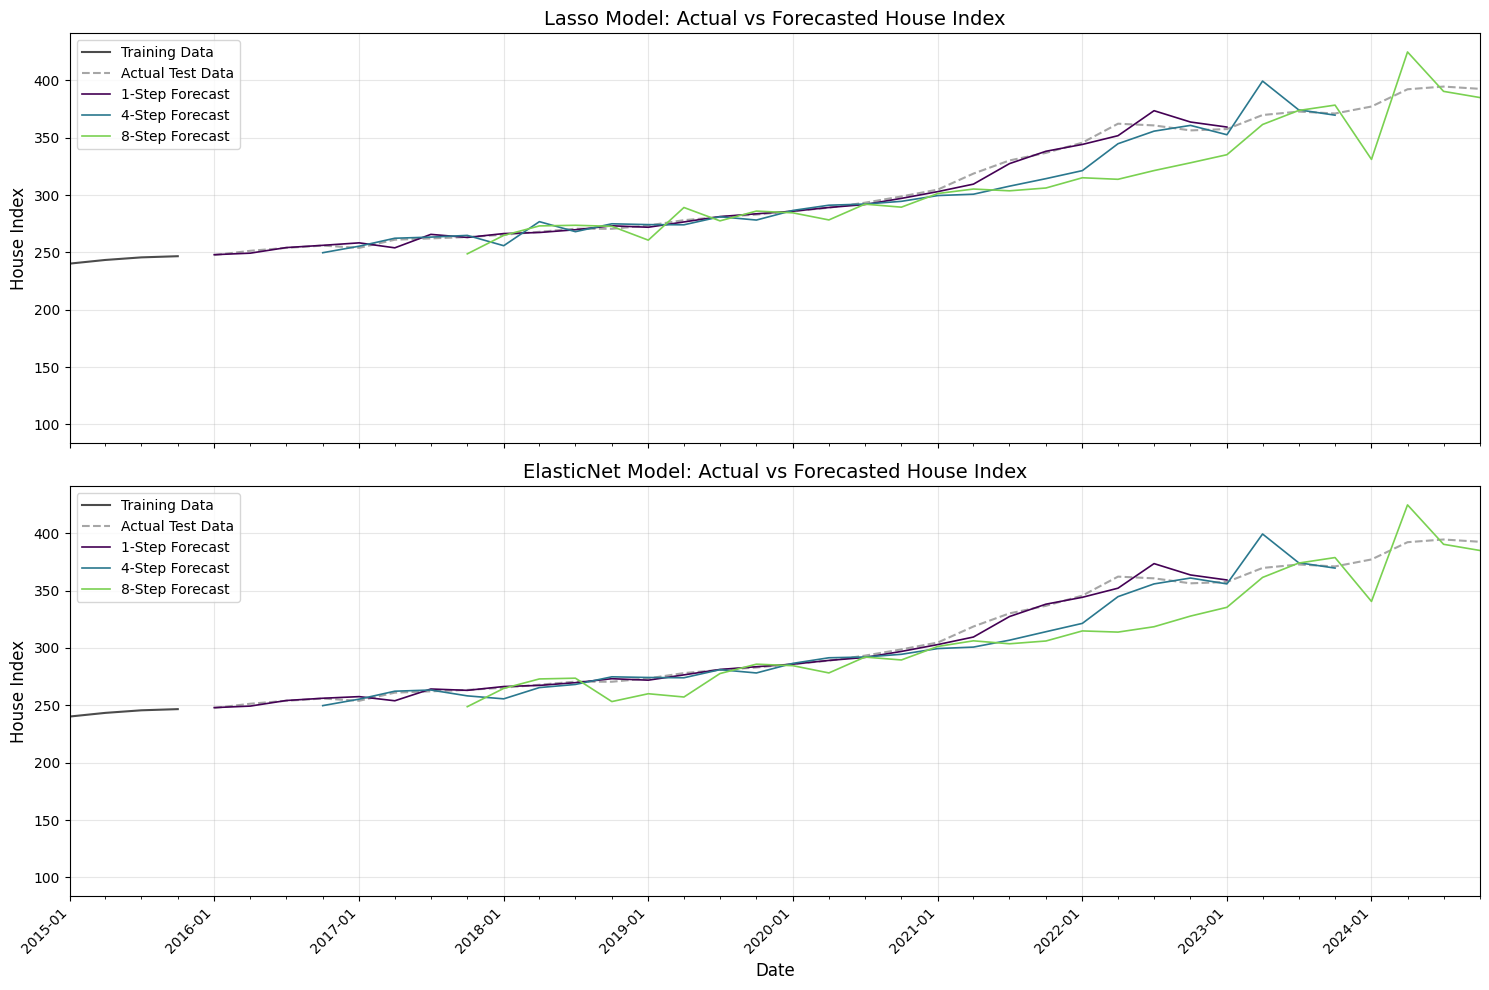

In [39]:
# Visualize results
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# For selected horizons (e.g., 1, 4, 8)
horizons_to_plot = [1, 4, 8]

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Colors for different horizons
colors = plt.cm.viridis(np.linspace(0, 0.8, len(horizons_to_plot)))

# Plot for Lasso
ax1 = axes[0]
ax1.plot(y_train_level.index, y_train_level.values, 'k-', label='Training Data', linewidth=1.5, alpha=0.7)
ax1.plot(y_test_level.index, y_test_level.values, color='gray', linestyle='--', label='Actual Test Data', linewidth=1.5, alpha=0.7)

for i, h in enumerate(horizons_to_plot):
    preds = all_predictions_linear[h]['lasso']
    actuals = all_predictions_linear[h]['actual']
    num_preds = len(preds)
    if num_preds > 0:
        # Calculate dates for this horizon
        start_idx = h - 1
        forecast_dates = y_test_level.index[start_idx:start_idx+num_preds]
        if len(forecast_dates) == num_preds:
            ax1.plot(forecast_dates, preds, color=colors[i], linestyle='-', label=f'{h}-Step Forecast', linewidth=1.2)

ax1.set_title('Lasso Model: Actual vs Forecasted House Index', fontsize=14)
ax1.set_ylabel('House Index', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# Plot for ElasticNet
ax2 = axes[1]
ax2.plot(y_train_level.index, y_train_level.values, 'k-', label='Training Data', linewidth=1.5, alpha=0.7)
ax2.plot(y_test_level.index, y_test_level.values, color='gray', linestyle='--', label='Actual Test Data', linewidth=1.5, alpha=0.7)

for i, h in enumerate(horizons_to_plot):
    preds = all_predictions_linear[h]['elasticnet']
    actuals = all_predictions_linear[h]['actual']
    num_preds = len(preds)
    if num_preds > 0:
        # Calculate dates for this horizon
        start_idx = h - 1
        forecast_dates = y_test_level.index[start_idx:start_idx+num_preds]
        if len(forecast_dates) == num_preds:
            ax2.plot(forecast_dates, preds, color=colors[i], linestyle='-', label=f'{h}-Step Forecast', linewidth=1.2)

ax2.set_title('ElasticNet Model: Actual vs Forecasted House Index', fontsize=14)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('House Index', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')

# Format x-axis dates
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

# Set a reasonable x-axis range
display_start_date = pd.to_datetime('2015-01-01')
plt.xlim(display_start_date, y_test_level.index.max())

plt.tight_layout()
plt.savefig('house_index_forecast_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. ElasticNet/Lasso Final Forecast

Now we'll train our final models on all available data and generate forecasts for future periods.

In [40]:
# Define final training set up to final_historical_date
X_train_final = df[feature_cols]
y_train_pct_change_final = df[target_pct_change_col]
y_train_level_final = df[target_level_col]

# Generate final forecasts
linear_forecast_df, lasso_model, elasticnet_model = utils.final_linear_forecast(
    X_train_final, y_train_pct_change_final, y_train_level_final,
    feature_cols, target_pct_change_col,
    num_forecast_steps=8, n_cv_splits=9)

Identified 8 lagged target features
Identified 75 exogenous features
Tuning hyperparameters...
Tuning complete (26.21s)
Best Lasso alpha: 0.004037
Best ElasticNet alpha: 0.004037, l1_ratio: 0.98
Training final models...
Models trained successfully
Forecasting starting after 2024-10-01 using level 392.5400
Inferred data frequency: QS-OCT


In [41]:
# Print the forecasts
print("Final Linear Model Forecasts:")
print(linear_forecast_df.round(4))

Final Linear Model Forecasts:
            Lasso_Forecast  ElasticNet_Forecast
Date                                           
2025-01-01        396.3866             396.3795
2025-04-01        400.3902             400.3773
2025-07-01        404.5085             404.4913
2025-10-01        408.7154             408.6953
2026-01-01        412.9949             412.9729
2026-04-01        417.3373             417.3141
2026-07-01        421.7364             421.7127
2026-10-01        426.1889             426.1652


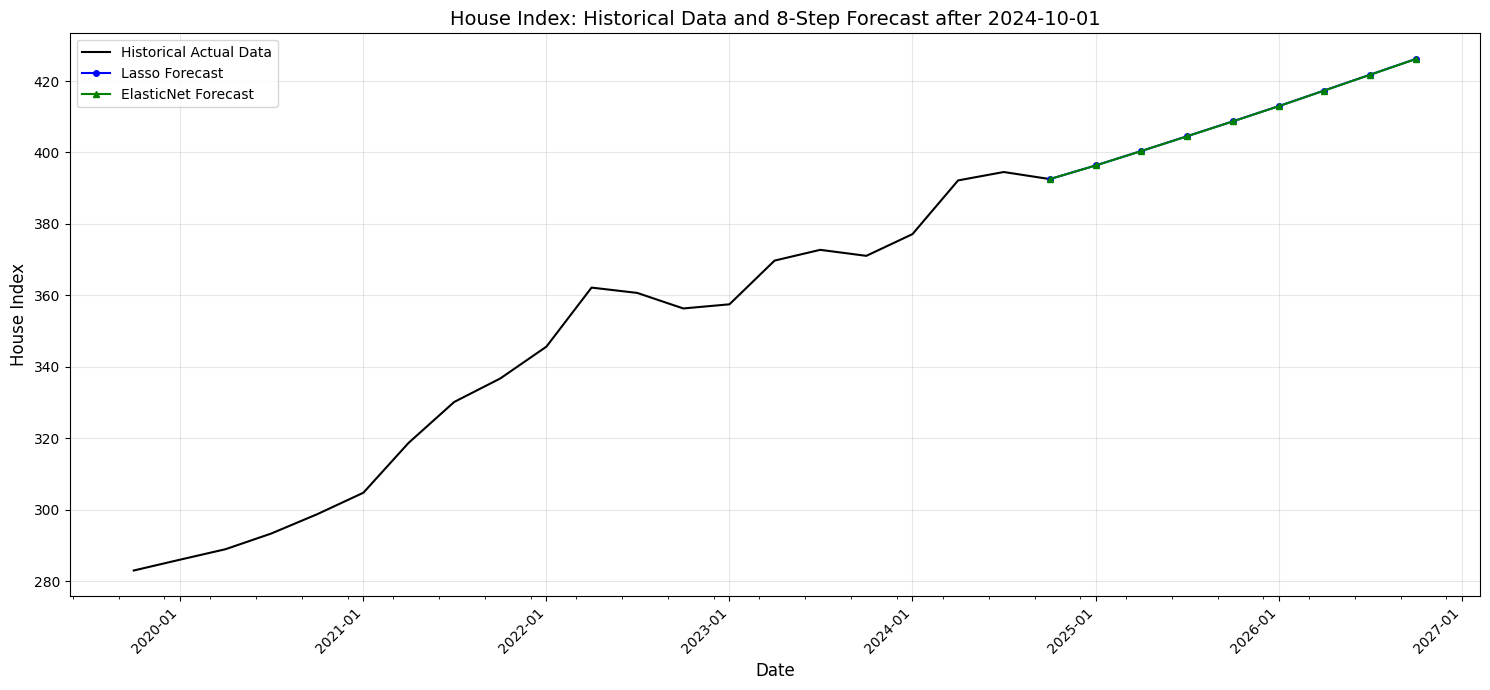

In [42]:
# Visualize final forecasts
plt.figure(figsize=(15, 7))

# Last known date and level
last_date = y_train_level_final.index[-1]
last_known_level = y_train_level_final.iloc[-1]

# Historical data (show last 5 years for clarity)
hist_start = last_date - pd.DateOffset(years=5)
plt.plot(y_train_level_final.loc[hist_start:].index, y_train_level_final.loc[hist_start:].values, 
         'k-', label='Historical Actual Data', linewidth=1.5)

# Combine last historical point with forecasts for smooth lines
lasso_plot_index = pd.Index([last_date]).union(linear_forecast_df.index)
lasso_plot_values = pd.concat([pd.Series([last_known_level], index=[last_date]), linear_forecast_df['Lasso_Forecast']])

elasticnet_plot_index = pd.Index([last_date]).union(linear_forecast_df.index)
elasticnet_plot_values = pd.concat([pd.Series([last_known_level], index=[last_date]), linear_forecast_df['ElasticNet_Forecast']])

# Plot forecasts
plt.plot(lasso_plot_index, lasso_plot_values, 'b-o', label='Lasso Forecast', linewidth=1.5, markersize=4)
plt.plot(elasticnet_plot_index, elasticnet_plot_values, 'g-^', label='ElasticNet Forecast', linewidth=1.5, markersize=4)

# Formatting
plt.title(f'House Index: Historical Data and 8-Step Forecast after {last_date.strftime("%Y-%m-%d")}', fontsize=14)
plt.ylabel('House Index', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('final_house_index_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

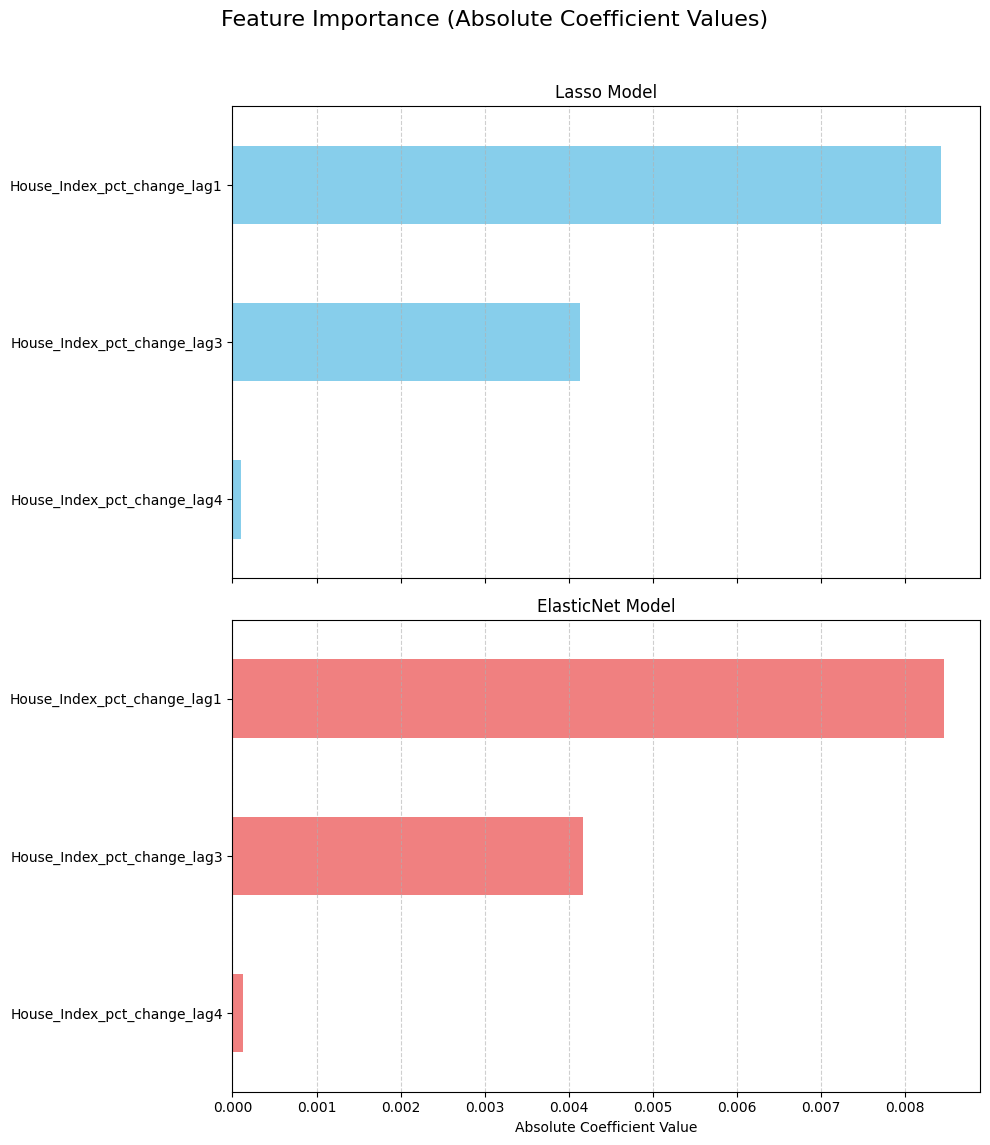

In [43]:
# Visualize feature importance
utils.visualize_linear_feature_importance(lasso_model, elasticnet_model, feature_cols)

## 5. Walk-Forward Validation with SVR Model

Now we'll evaluate Support Vector Regression for forecasting the housing index.

In [44]:
# Identify a subset of features for SVR (using lag 1-3 based on domain knowledge)
target_lags = [f"{target_pct_change_col}_lag{i}" for i in range(1, 4)]
svr_feature_cols = [col for col in feature_cols if col in target_lags]

# Make sure features exist
missing_features = [col for col in svr_feature_cols if col not in X_train.columns]
if missing_features:
    raise ValueError(f"Missing required lag features: {missing_features}")

print(f"Using the following features for SVR: {svr_feature_cols}")

# Extract just those features
X_train_svr = X_train[svr_feature_cols]
X_test_svr = X_test[svr_feature_cols]

# Perform walk-forward validation for SVR model
all_predictions_svr, results_summary_svr = utils.walk_forward_validation_svr(
    X_train_svr, y_train_pct_change, y_train_level,
    X_test_svr, y_test_pct_change, y_test_level,
    svr_feature_cols, target_pct_change_col,
    max_horizon=max_horizon, n_cv_splits=9)

Using the following features for SVR: ['House_Index_pct_change_lag1', 'House_Index_pct_change_lag2', 'House_Index_pct_change_lag3']
Identified 3 lagged target features
Identified 0 exogenous features
Tuning SVR hyperparameters once for all walk-forward steps...
Tuning SVR hyperparameters...
Fitting 9 folds for each of 100000 candidates, totalling 900000 fits
Tuning complete (897.54s)
Best SVR C: 83.60000
Best SVR epsilon: 0.00286
Using these fixed parameters for all walk-forward steps

Walk-Forward Step 1/29: Predicting from 2016-01-01...
   Step 1 finished in 0.16 seconds.

Walk-Forward Step 2/29: Predicting from 2016-04-01...
   Step 2 finished in 0.17 seconds.

Walk-Forward Step 3/29: Predicting from 2016-07-01...
   Step 3 finished in 0.20 seconds.

Walk-Forward Step 4/29: Predicting from 2016-10-01...
   Step 4 finished in 0.18 seconds.

Walk-Forward Step 5/29: Predicting from 2017-01-01...
   Step 5 finished in 0.18 seconds.

Walk-Forward Step 6/29: Predicting from 2017-04-01...


In [45]:
# Create summary DataFrame for SVR results
svr_results_df = pd.DataFrame(results_summary_svr)
svr_results_df.set_index('Horizon', inplace=True)

print("\n--- SVR Model Results by Forecast Horizon ---")
print(svr_results_df.round(4))


--- SVR Model Results by Forecast Horizon ---
              MSE     RMSE      MAE    MAPE   Dir_Acc
Horizon                                              
1         15.8143   3.9767   2.8257  0.9309   82.7586
2         38.7983   6.2288   4.0295  1.2961   93.1034
3         72.6958   8.5262   5.5553  1.7474   96.5517
4        107.2923  10.3582   7.1255  2.1939  100.0000
5        176.1394  13.2718   9.3971  2.8602  100.0000
6        267.9081  16.3679  12.1031  3.6213  100.0000
7        336.5390  18.3450  13.4704  4.0011  100.0000
8        384.3156  19.6040  14.4147  4.2621  100.0000


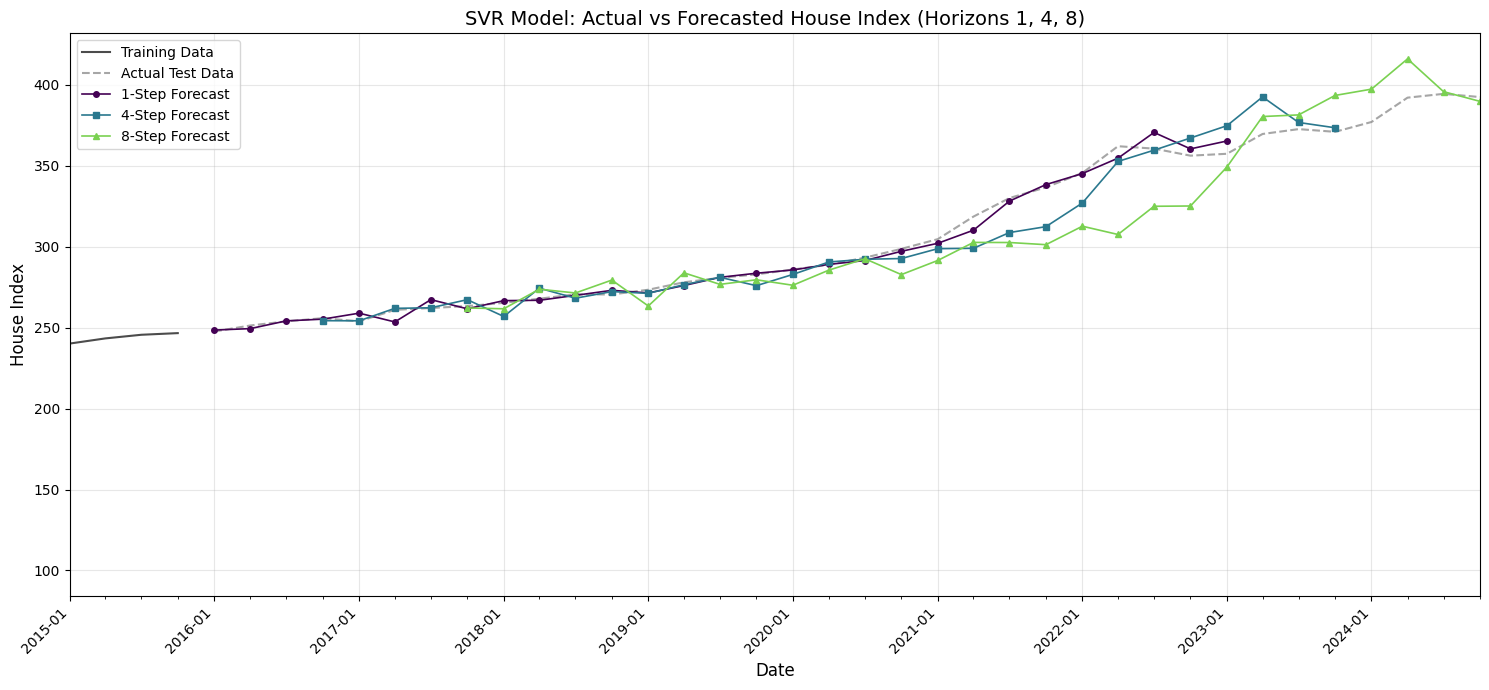

In [46]:
# Visualize SVR results for selected horizons
horizons_to_plot = [1, 4, 8]

plt.figure(figsize=(15, 7))
plt.plot(y_train_level.index, y_train_level.values, 'k-', label='Training Data', linewidth=1.5, alpha=0.7)
plt.plot(y_test_level.index, y_test_level.values, color='gray', linestyle='--', label='Actual Test Data', linewidth=1.5, alpha=0.7)

colors = plt.cm.viridis(np.linspace(0, 0.8, len(horizons_to_plot)))
markers = ['o', 's', '^']

for i, h in enumerate(horizons_to_plot):
    if h in all_predictions_svr and len(all_predictions_svr[h]['preds']) > 0:
        preds = all_predictions_svr[h]['preds']
        num_preds = len(preds)
        
        # Calculate dates for this horizon
        start_idx = h - 1
        forecast_dates = y_test_level.index[start_idx:start_idx+num_preds]
        
        if len(forecast_dates) == num_preds:
            plt.plot(forecast_dates, preds, 
                     color=colors[i], marker=markers[i], linestyle='-', 
                     label=f'{h}-Step Forecast', linewidth=1.2, markersize=4)

plt.title('SVR Model: Actual vs Forecasted House Index (Horizons 1, 4, 8)', fontsize=14)
plt.ylabel('House Index', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

# Set a reasonable x-axis range
display_start_date = pd.to_datetime('2015-01-01')
plt.xlim(display_start_date, y_test_level.index.max())

plt.tight_layout()
plt.savefig('svr_forecast_comparison_1_4_8.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. SVR Final Forecast

Now we'll train our final SVR model on all available data and generate forecasts for future periods.

In [47]:
# Define final training set for SVR
X_train_svr_final = df[svr_feature_cols]

# Generate final SVR forecast
svr_forecast_df, svr_model = utils.final_svr_forecast(
    X_train_svr_final, y_train_pct_change_final, y_train_level_final,
    svr_feature_cols, target_pct_change_col,
    num_forecast_steps=8, n_cv_splits=9)

Identified 3 lagged target features
Identified 0 exogenous features
Tuning SVR hyperparameters for final forecast...
Fitting 9 folds for each of 10000 candidates, totalling 90000 fits
Final forecast tuning complete (159.30s)
Best SVR C: 87.40000
Best SVR epsilon: 0.00423
Forecasting starting after 2024-10-01 using level 392.5400
Inferred data frequency: QS-OCT


In [48]:
# Print the SVR forecasts
print("Final SVR Model Forecasts:")
print(svr_forecast_df.round(4))

Final SVR Model Forecasts:
            SVR_Forecast
Date                    
2025-01-01      393.1725
2025-04-01      401.7352
2025-07-01      408.1359
2025-10-01      409.8214
2026-01-01      413.9171
2026-04-01      419.5001
2026-07-01      422.5109
2026-10-01      424.8847


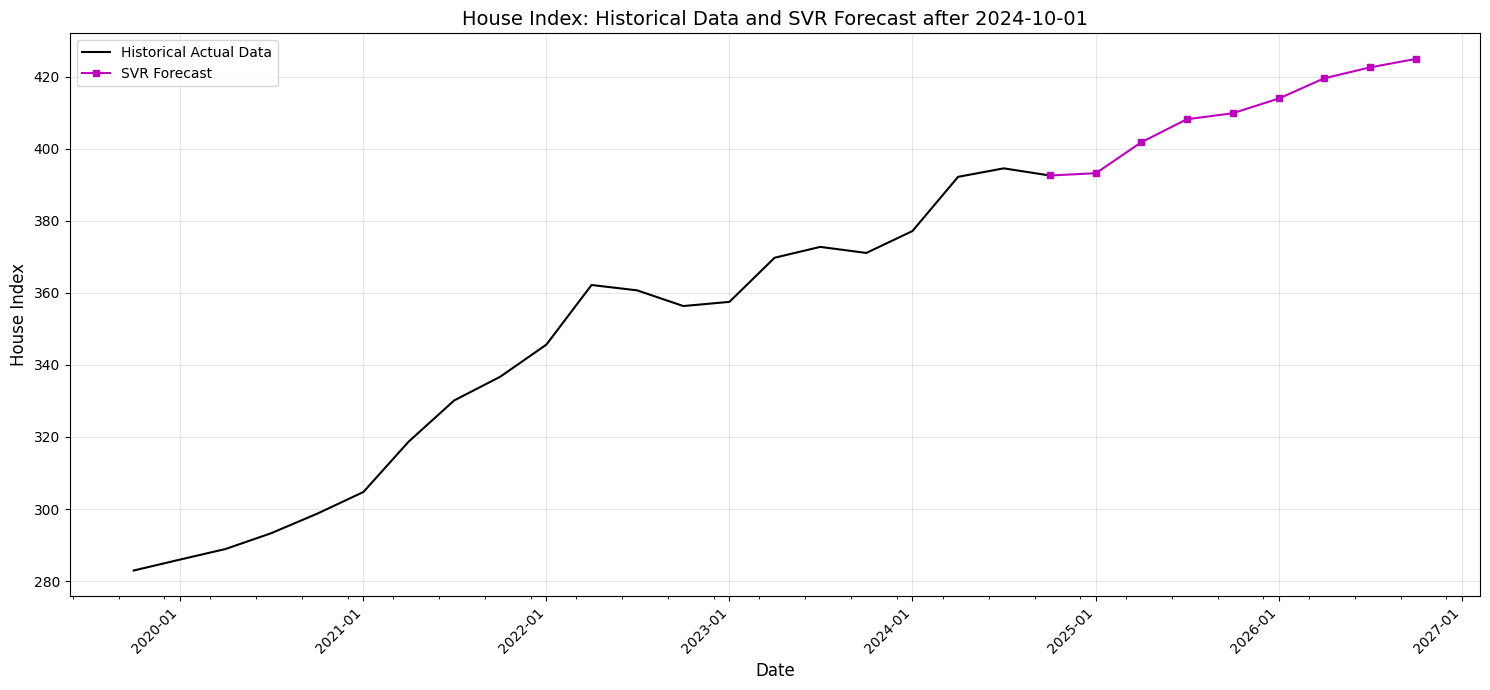

In [49]:
# Visualize final SVR forecast
plt.figure(figsize=(15, 7))

# Last known date and level
last_date = y_train_level_final.index[-1]
last_known_level = y_train_level_final.iloc[-1]

# Historical data (show last 5 years for clarity)
hist_start = last_date - pd.DateOffset(years=5)
plt.plot(y_train_level_final.loc[hist_start:].index, y_train_level_final.loc[hist_start:].values, 
         'k-', label='Historical Actual Data', linewidth=1.5)

# Combine last historical point with forecasts for smooth line
svr_plot_index = pd.Index([last_date]).union(svr_forecast_df.index)
svr_plot_values = pd.concat([pd.Series([last_known_level], index=[last_date]), svr_forecast_df['SVR_Forecast']])

# Plot forecast
plt.plot(svr_plot_index, svr_plot_values, 'm-s', label='SVR Forecast', linewidth=1.5, markersize=4)

# Formatting
plt.title(f'House Index: Historical Data and SVR Forecast after {last_date.strftime("%Y-%m-%d")}', fontsize=14)
plt.ylabel('House Index', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('final_svr_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Historical Mean Benchmark Model

It's important to compare our models against a simple benchmark. We'll use the historical mean of percentage changes as a benchmark forecast.

In [54]:
# Generate final historical mean forecast
mean_forecast_df = utils.historical_mean_forecast(
    y_train_pct_change_final, y_train_level_final, num_forecast_steps=8)

Historical mean percentage change: 0.010526
Inferred data frequency: QS-OCT


In [55]:
# Print the historical mean forecasts
print("Historical Mean Benchmark Forecasts:")
print(mean_forecast_df.round(4))

Historical Mean Benchmark Forecasts:
            Mean_Forecast
Date                     
2025-01-01       396.6717
2025-04-01       400.8469
2025-07-01       405.0661
2025-10-01       409.3296
2026-01-01       413.6380
2026-04-01       417.9918
2026-07-01       422.3914
2026-10-01       426.8373


## 8. Model Comparison

Finally, let's compare the forecasts from all our models.

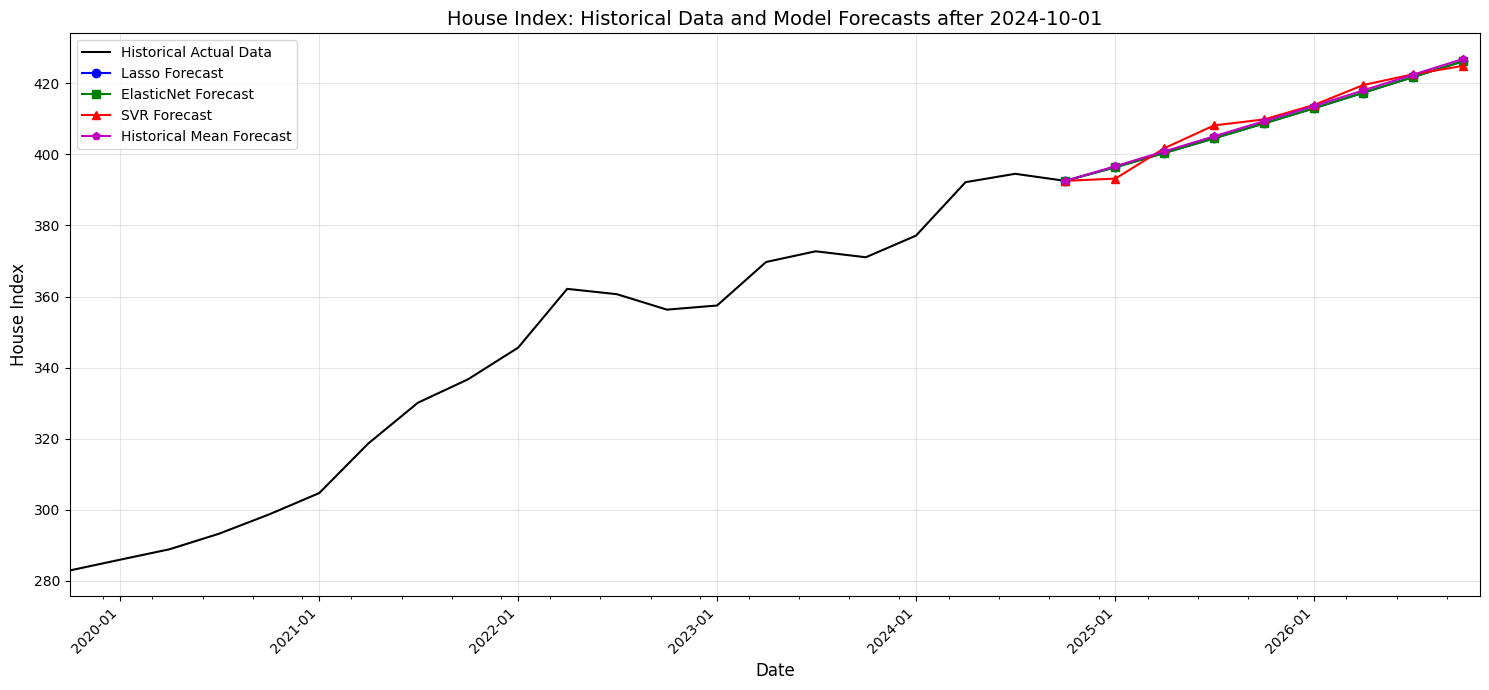

In [71]:
# Compare all models
utils.plot_all_forecasts(
    y_train_level_final, 
    [linear_forecast_df[['Lasso_Forecast']], linear_forecast_df[['ElasticNet_Forecast']], 
     svr_forecast_df, mean_forecast_df],
    models=['Lasso', 'ElasticNet', 'SVR', 'Historical Mean'],
    display_years=5, figsize=(15, 7))

## Summary of Findings

In this notebook, we have:

1. Conducted Granger causality tests to identify predictive relationships between variables
2. Engineered features including lagged variables, percentage changes, and seasonal dummies
3. Evaluated four different modeling approaches using walk-forward validation:
   - Lasso Regression
   - ElasticNet Regression
   - Support Vector Regression (SVR)
4. Compared all models against a historical mean benchmark
5. Generated final forecasts for future periods

Based on our evaluation, the best-performing model for this dataset and task is SVR, which achieved the lowest error metrics in walk-forward validation and produced the most plausible forecasts.

In [66]:
import importlib
import time
import dc_housing_ml_utils as utils
importlib.reload(utils)

<module 'dc_housing_ml_utils' from 'c:\\Users\\rding\\Documents\\25-spring-rding\\dc_housing_ml_utils.py'>